# RSSI Analyzer — Model 2 **v2**: RSU-tier XGBoost (pipeline-aligned)

Aligned to the fusion spine (`ml/fusion/identity_manifest.py`): same identity subsample,
leakage-safe split, and **2 s export grid** as RSSI-CNN v2 / GRU v3 / trust v2.

- Data: the 3 pct-sweep runs (`pct20_s1`, `pct40_s1`, `pct100_s1`), streamed memory-safe.
- Windows: **5 s span / 2 s step** (doc), left-edge snapped to the shared 2 s grid.
- Labels: **7-class** `attack_type ∈ {0..6}` (softmax); `p̄_RSSI = 1 − P(legit)` (Eq 3.19).

### v2 fix (this revision)

**Sentinel contamination (the real reason "honest" was low).** `rssi_dbm == 40.0` is a
*"no valid measurement"* sentinel (≈79 % of rows; aligns 1:1 with
`rssi_estimated_distance_m == 0`). Real RSSI is −60…−82 dBm. The old `rssi_mean/std/min/max`
averaged the real dBm together with the `+40` sentinel, so they mostly encoded *how often
the sentinel fired* — garbage. **Fix:** RSSI stats are now computed over **valid rows only**,
and the sentinel rate is surfaced explicitly as an honest `valid_rate` feature.

- **Feature set (`honest`, leakage-free):** sentinel-safe RSSI stats (valid-only) +
  `valid_rate` + observable RSU-tier geometry (`observer_count`, `beacons_per_observer`,
  `n_beacons`, claimed-position distance). Uses **no ground-truth id and no idealised
  physics** → leakage-free; this is the exported feed.
- Exports on-contract to `notebooks/outputs/`: `rssi_xgb_rsu.parquet`, key =
  `[run_id, attack_percentage, claimed_node_id, window_start_seconds, split]`, col `p_bar_rssi`.

In [11]:
import os, json, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import (matthews_corrcoef, confusion_matrix, classification_report,
                             accuracy_score, f1_score, recall_score)
from xgboost import XGBClassifier
import joblib

BASE_DIR = '/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack'

# ── Shared fusion spine (single source of truth): identical identity subsample,
#    leakage-safe split, and 2 s export grid as RSSI-CNN v2 / GRU v3 / trust v2, so this
#    parquet joins on (run_id, attack_percentage, claimed_node_id, window_start_seconds, split).
sys.path.insert(0, f'{BASE_DIR}/ml/fusion')
import identity_manifest as IDM
MAN           = IDM.load_manifest()
RUN_DIRS      = IDM.RUN_DIRS
ARTIFACTS_DIR = str(IDM.ARTIFACTS_DIR)          # notebooks/outputs  (contract exports land here)
EXPORT_GRID_S = IDM.EXPORT_GRID_S               # 2.0 s

OUTPUT_DIR = f'{BASE_DIR}/ml/Outputs_RSSI_XGB'  # model/plots/results (non-contract)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 7-class taxonomy (index == attack_type); phase attack_type 1..6 maps directly to 1..6.
CLASS_NAMES = ['legitimate', 'outsider', 'sim', 'nonsim', 'indirect',
               'malicious_rsu', 'malicious_controller']
N_CLASSES = len(CLASS_NAMES)
LEGIT = 0

WINDOW_SEC = 5.0     # doc: 5 s aggregation span
STEP_SEC   = 2.0     # doc: 2 s step == shared export grid
SEED       = 42

# ── Sentinel handling ──
# rssi_dbm == 40.0 is a "no valid measurement" placeholder (real RSSI is negative dBm);
# it is ~79% of rows and aligns 1:1 with rssi_estimated_distance_m == 0. RSSI aggregates
# MUST be computed over valid rows only, else the mean/std/min/max encode the sentinel, not
# the signal (this was the bug behind the old honest MCC~0.33). The sentinel *rate* is itself
# a real observable, so it is surfaced separately as the honest `valid_rate` feature.
RSSI_SENTINEL = 40.0
RSSI_FILL     = -100.0   # placeholder RSSI for windows with zero valid measurements (flagged by valid_rate=0)

# ── Feature set (honest, leakage-free) ──
#   sentinel-safe RSSI stats (valid rows only) + valid_rate + observable RSU-tier geometry
#   (distinct observers, beacon density, claimed-position distance). No ground-truth id, no
#   idealised RSSI->distance physics. This is the exported feed.
FEATURE_SETS = {
    'honest': ['valid_rate', 'rssi_mean', 'rssi_std', 'rssi_min', 'rssi_max',
               'observer_count', 'beacons_per_observer', 'n_beacons',
               'claimed_dist_mean', 'claimed_dist_std'],
}
# hard-leak columns (rule verdicts / ground-truth ids) that must NEVER be features.
HARD_LEAK = {'threshold_m', 'verification_state', 'suspicion_flags',
             'is_sybil', 'real_id', 'claimed_id', 'claimed_node_id', 'run_id'}
for _nm, _fs in FEATURE_SETS.items():
    assert not (set(_fs) & HARD_LEAK), f'{_nm}: hard-leak column in features'

XGB_HP = dict(
    n_estimators=300, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=2.0, min_child_weight=4,
    tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0,
)  # objective/num_class inferred by XGBClassifier from the 7-class labels present


def assign_attack_type(times, phase_df):
    '''Phase attack_type (1..6) per beacon time; 0 before the first phase.
    Matches RSSI-CNN v2 / trust_v2 (searchsorted on phase start_time).'''
    starts = phase_df['start_time'].to_numpy(dtype=float)
    types  = phase_df['attack_type'].to_numpy()
    idx = np.searchsorted(starts, np.asarray(times, dtype=float), side='right') - 1
    out = np.zeros(len(idx), dtype=np.int64); ok = idx >= 0
    out[ok] = types[idx[ok]]
    return out


def full_proba(model, X):
    '''predict_proba padded to a fixed (N, 7) matrix regardless of which classes the
    model actually saw in training (classes 5/6 are ~absent at the vehicle tier).'''
    p = model.predict_proba(X)
    full = np.zeros((len(X), N_CLASSES), dtype=np.float32)
    for j, c in enumerate(model.classes_):
        full[:, int(c)] = p[:, j]
    return full


print('runs        :', [os.path.basename(r) for r in RUN_DIRS])
print('feature sets:', {k: len(v) for k, v in FEATURE_SETS.items()})

runs        : ['pct100_s1', 'pct20_s1', 'pct40_s1']
feature sets: {'honest': 10}


## Step 1 — Load, label (7-class) & window each pct-sweep run (memory-safe)

In [2]:
def build_rsu_features(df, run_id, pct, window_sec=WINDOW_SEC, step_sec=STEP_SEC):
    '''5 s / 2 s sliding windows per claimed identity -> one feature row per
    (claimed_node_id, grid-aligned window_start). Computes columns for BOTH feature
    sets; the model cell selects which to use. window_start is floored to the 2 s grid
    so rows land on the shared spine grid and join.

    Sentinel-safe: rssi_dbm == RSSI_SENTINEL (== 40.0, "no valid measurement") is excluded
    from every RSSI aggregate. `valid_rate` carries the sentinel rate as an explicit,
    honest observable; windows with zero valid beacons get RSSI_FILL and valid_rate == 0.'''
    records = []
    for cid, grp in df.groupby('observed_claimed_id', sort=False):
        grp   = grp.sort_values('time')
        t_arr = grp['time'].values.astype(float)
        real  = int(grp['observed_real_id'].iloc[0])
        rssi  = grp['rssi_dbm'].values.astype(float)
        valid = grp['valid'].values                                    # ~sentinel mask (bool)
        d_cl  = np.maximum(grp['claimed_distance_m'].values.astype(float), 1.0)  # floor to avoid ratio blow-up
        obs   = grp['observer_vehicle_id'].values
        atk   = grp['attack_type'].values
        t = np.floor(t_arr.min() / step_sec) * step_sec      # grid-aligned first window
        tmax = t_arr.max()
        while t < tmax:
            m = (t_arr >= t) & (t_arr < t + window_sec)
            ntot = int(m.sum())
            if ntot < 2:
                t += step_sec; continue
            aw  = atk[m]
            lab = int(pd.Series(aw[aw > 0]).mode().iloc[0]) if (aw > 0).any() else 0
            vm  = m & valid                                            # valid RSSI rows in window
            nv  = int(vm.sum())
            rv  = rssi[vm]
            nobs = int(pd.unique(obs[m]).size)
            records.append({
                'run_id'              : run_id,
                'attack_percentage'   : pct,
                'claimed_node_id'     : int(cid),
                'real_id'             : real,
                'window_start_seconds': float(t),
                'attack_type'         : lab,
                'is_sybil'            : int(lab != 0),
                # ── honest features (leakage-free: no ground-truth id, no idealised physics) ──
                'valid_rate'          : nv / ntot,                     # sentinel rate (real observable)
                'rssi_mean'           : float(rv.mean()) if nv    else RSSI_FILL,   # valid-only stats
                'rssi_std'            : float(rv.std())  if nv > 1 else 0.0,
                'rssi_min'            : float(rv.min())  if nv    else RSSI_FILL,
                'rssi_max'            : float(rv.max())  if nv    else RSSI_FILL,
                'observer_count'      : nobs,                          # distinct vehicles that heard this id
                'n_beacons'           : ntot,                         # beacon density in the window
                'beacons_per_observer': ntot / max(nobs, 1),
                'claimed_dist_mean'   : float(d_cl[m].mean()),        # distance to CLAIMED position (observable)
                'claimed_dist_std'    : float(d_cl[m].std()),
            })
            t += step_sec
    return pd.DataFrame(records)


RSSI_USE = ['time', 'observer_vehicle_id', 'observed_claimed_id', 'observed_real_id',
            'rssi_dbm', 'rssi_estimated_distance_m', 'claimed_distance_m']

parts = []
for run_dir in RUN_DIRS:
    meta   = json.load(open(f'{run_dir}/run_meta.json'))
    run_id = str(meta.get('run_id', os.path.basename(run_dir)))
    pct    = int(meta['sybil_attack_percentage'])
    ph     = next(p for p in os.listdir(run_dir) if p.startswith('attack_phases'))
    phases = pd.read_csv(f'{run_dir}/{ph}').sort_values('start_time')
    print(f'[{run_id}] pct{pct} — streaming rssi_verification_log ...')
    df = IDM.read_run_log_filtered(f'{run_dir}/rssi_verification_log.csv', RSSI_USE,
                                   'observed_claimed_id', run_id, MAN)
    df = df.drop_duplicates(subset=['time', 'observer_vehicle_id',
                                    'observed_claimed_id', 'observed_real_id', 'rssi_dbm'])
    df['is_sybil']    = (df['observed_claimed_id'] != df['observed_real_id']).astype('int8')
    ptype             = assign_attack_type(df['time'].values, phases)
    df['attack_type'] = np.where(df['is_sybil'].values == 1, ptype, 0).astype('int8')
    # sentinel mask: rssi_dbm == 40.0 (no valid measurement) <=> rssi_estimated_distance_m == 0
    df['valid'] = (df['rssi_dbm'].values != RSSI_SENTINEL) & (df['rssi_estimated_distance_m'].values > 0)
    print(f'    valid-RSSI rate: {df["valid"].mean():.1%}  (rest is the {RSSI_SENTINEL:.0f} dBm sentinel)')
    feats = build_rsu_features(df, run_id, pct)
    print(f'    -> {len(feats):,} windows  ({int(feats.is_sybil.sum()):,} sybil, '
          f'{feats.claimed_node_id.nunique()} ids)')
    parts.append(feats)
    del df

feat_df = pd.concat(parts, ignore_index=True)
feat_df['window_start_seconds'] = IDM.snap_grid(feat_df['window_start_seconds'])
print(f'\nTotal windows: {len(feat_df):,}')
print('attack_type dist:',
      {CLASS_NAMES[k]: int(v) for k, v in feat_df['attack_type'].value_counts().sort_index().items()})
feat_df.head(3)

[pct100_s1] pct100 — streaming rssi_verification_log ...


    [safe-read] rssi_verification_log.csv: scanned 53,839,340 rows, kept 27,391,335 (50.9%)
    valid-RSSI rate: 11.3%  (rest is the 40 dBm sentinel)
    -> 21,352 windows  (9,076 sybil, 822 ids)
[pct20_s1] pct20 — streaming rssi_verification_log ...
    [safe-read] rssi_verification_log.csv: scanned 62,677,278 rows, kept 26,044,070 (41.6%)
    valid-RSSI rate: 9.4%  (rest is the 40 dBm sentinel)
    -> 15,734 windows  (3,359 sybil, 277 ids)
[pct40_s1] pct40 — streaming rssi_verification_log ...
    [safe-read] rssi_verification_log.csv: scanned 60,795,090 rows, kept 22,962,976 (37.8%)
    valid-RSSI rate: 10.8%  (rest is the 40 dBm sentinel)
    -> 17,755 windows  (5,747 sybil, 428 ids)

Total windows: 54,841
attack_type dist: {'legitimate': 36659, 'outsider': 5482, 'sim': 7093, 'nonsim': 3368, 'indirect': 1973, 'malicious_rsu': 266}


,run_id,attack_percentage,claimed_node_id,real_id,window_start_seconds,attack_type,is_sybil,valid_rate,rssi_mean,rssi_std,rssi_min,rssi_max,observer_count,n_beacons,beacons_per_observer,claimed_dist_mean,claimed_dist_std
0,pct100_s1,100,461,0,2.0,1,1,1.0,-78.508092,2.300409,-81.558403,-73.946198,1,46,46.0,79.548887,11.439143
1,pct100_s1,100,461,0,4.0,1,1,1.0,-80.727373,1.249369,-81.983398,-77.765404,1,50,50.0,91.166897,7.266738
2,pct100_s1,100,461,0,6.0,1,1,1.0,-81.491527,0.365044,-81.983398,-80.719002,1,46,46.0,95.157987,2.657463


## Step 2 — Attach the shared leakage-safe split (from `split_map`)

In [3]:
# Shared split (grouped by real vehicle in the manifest — no cross-split leakage).
# inner-join: rows whose (run_id, claimed_node_id) is outside the subsample are dropped.
feat_df = IDM.attach_split(feat_df, MAN)

print('windows after split attach:', len(feat_df))
print('split :', feat_df['split'].value_counts().to_dict())
print('ids   :', feat_df['claimed_node_id'].nunique())
print('runs  :', feat_df['run_id'].value_counts().to_dict())
feat_df[['run_id', 'claimed_node_id', 'window_start_seconds', 'split',
         'attack_type', 'is_sybil']].head(3)

windows after split attach: 54841
split : {'train': 37765, 'test': 9175, 'val': 7901}
ids   : 1185
runs  : {'pct100_s1': 21352, 'pct40_s1': 17755, 'pct20_s1': 15734}


,run_id,claimed_node_id,window_start_seconds,split,attack_type,is_sybil
0,pct100_s1,461,2.0,train,1,1
1,pct100_s1,461,4.0,train,1,1
2,pct100_s1,461,6.0,train,1,1


## Step 3 — Split masks (shared 70/15/15) + 7-class labels

In [4]:
# Boolean split masks + shared 7-class label vector. Both feature sets train/eval on the
# SAME rows (only the X columns differ), so the comparison is apples-to-apples.
tr = (feat_df['split'] == 'train').values
va = (feat_df['split'] == 'val').values
te = (feat_df['split'] == 'test').values
y  = feat_df['attack_type'].astype(int).values

print(f'train {tr.sum():,}   val {va.sum():,}   test {te.sum():,}')
for nm, fs in FEATURE_SETS.items():
    print(f'  {nm:6s}: {fs}')
assert not feat_df[sum(FEATURE_SETS.values(), [])].isna().any().any(), 'NaNs in features'

train 37,765   val 7,901   test 9,175
  honest: ['valid_rate', 'rssi_mean', 'rssi_std', 'rssi_min', 'rssi_max', 'observer_count', 'beacons_per_observer', 'n_beacons', 'claimed_dist_mean', 'claimed_dist_std']


## Step 4 — Train 7-class XGBoost per feature set (max_depth ∈ {5,6,7}, early stop on val MCC)

In [5]:
def train_one(feats):
    Xtr, Xva = feat_df.loc[tr, feats], feat_df.loc[va, feats]
    ytr, yva = y[tr], y[va]
    best_mcc, best_depth, best_model = -1.0, 6, None
    for depth in [5, 6, 7]:
        m = XGBClassifier(max_depth=depth, early_stopping_rounds=30, **XGB_HP)
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        vmcc = matthews_corrcoef(yva, m.predict(Xva))
        ntrees = (m.best_iteration + 1) if hasattr(m, 'best_iteration') else XGB_HP['n_estimators']
        print(f'    depth={depth}  val MCC={vmcc:.4f}  trees={ntrees}')
        if vmcc > best_mcc:
            best_mcc, best_depth, best_model = vmcc, depth, m
    print(f'  best depth={best_depth}  val MCC={best_mcc:.4f}')
    return dict(val_mcc=best_mcc, depth=best_depth, model=best_model)

models = {}
for nm, fs in FEATURE_SETS.items():
    print(f'[{nm}] training 7-class XGB ({len(fs)} features) ...')
    models[nm] = train_one(fs)

[honest] training 7-class XGB (10 features) ...


    depth=5  val MCC=0.8392  trees=300
    depth=6  val MCC=0.8462  trees=300
    depth=7  val MCC=0.8489  trees=300
  best depth=7  val MCC=0.8489


In [6]:
def evaluate(nm, feats, model):
    yte  = y[te]
    pred = model.predict(feat_df.loc[te, feats])
    mcc  = matthews_corrcoef(yte, pred)
    acc  = accuracy_score(yte, pred)
    f1   = f1_score(yte, pred, average='macro')
    bt, bp = (yte != 0).astype(int), (pred != 0).astype(int)     # sybil-vs-legit view
    tn = int(((bt == 0) & (bp == 0)).sum()); fp = int(((bt == 0) & (bp == 1)).sum())
    fpr = fp / max(tn + fp, 1)
    print(f'\n[{nm}] test 7-class:  MCC={mcc:.4f}  acc={acc:.4f}  f1_macro={f1:.4f}  '
          f'| sybil recall={recall_score(bt, bp):.4f}  FPR={fpr:.4f}')
    print(classification_report(yte, pred, labels=list(range(N_CLASSES)),
                                target_names=CLASS_NAMES, zero_division=0))
    return dict(mcc=float(mcc), acc=float(acc), f1_macro=float(f1),
                sybil_recall=float(recall_score(bt, bp)), fpr=float(fpr))

metrics = {}
for nm, mi in models.items():
    metrics[nm] = evaluate(nm, FEATURE_SETS[nm], mi['model'])
    metrics[nm].update(best_depth=int(mi['depth']), val_mcc=float(mi['val_mcc']))

print('\n=== honest (test) ===')
print(f"{'':8s}{'MCC':>8}{'acc':>8}{'f1_mac':>8}{'recall':>8}{'FPR':>8}")
for nm, mm in metrics.items():
    print(f"{nm:8s}{mm['mcc']:8.4f}{mm['acc']:8.4f}{mm['f1_macro']:8.4f}"
          f"{mm['sybil_recall']:8.4f}{mm['fpr']:8.4f}")


[honest] test 7-class:  MCC=0.8390  acc=0.9174  f1_macro=0.7170  | sybil recall=0.9051  FPR=0.0074
                      precision    recall  f1-score   support

          legitimate       0.95      0.99      0.97      6109
            outsider       0.82      0.76      0.79       907
                 sim       0.87      0.81      0.84      1175
              nonsim       0.83      0.82      0.83       551
            indirect       0.75      0.68      0.71       379
       malicious_rsu       0.56      0.09      0.16        54
malicious_controller       0.00      0.00      0.00         0

            accuracy                           0.92      9175
           macro avg       0.68      0.59      0.61      9175
        weighted avg       0.91      0.92      0.91      9175


=== honest (test) ===
             MCC     acc  f1_mac  recall     FPR
honest    0.8390  0.9174  0.7170  0.9051  0.0074


In [7]:
# Leakage audit — honest feature importances (gain). No single feature should dominate the
# way a leaky ground-truth column would; signal is spread across sentinel-rate, RSSI level,
# observer geometry and claimed-distance — all observable at the RSU without ground truth.
for nm in ['honest']:
    fs  = FEATURE_SETS[nm]
    imp = sorted(zip(fs, models[nm]['model'].feature_importances_), key=lambda x: -x[1])
    print(f'[{nm}] feature importance (gain-normalised):')
    for f, v in imp:
        print(f'    {f:22s} {v:.3f}  {"#" * int(round(v * 50))}')

[honest] feature importance (gain-normalised):
    valid_rate             0.309  ###############
    beacons_per_observer   0.188  #########
    observer_count         0.127  ######
    claimed_dist_mean      0.086  ####
    n_beacons              0.062  ###
    rssi_min               0.056  ###
    claimed_dist_std       0.051  ###
    rssi_mean              0.042  ##
    rssi_max               0.042  ##
    rssi_std               0.036  ##


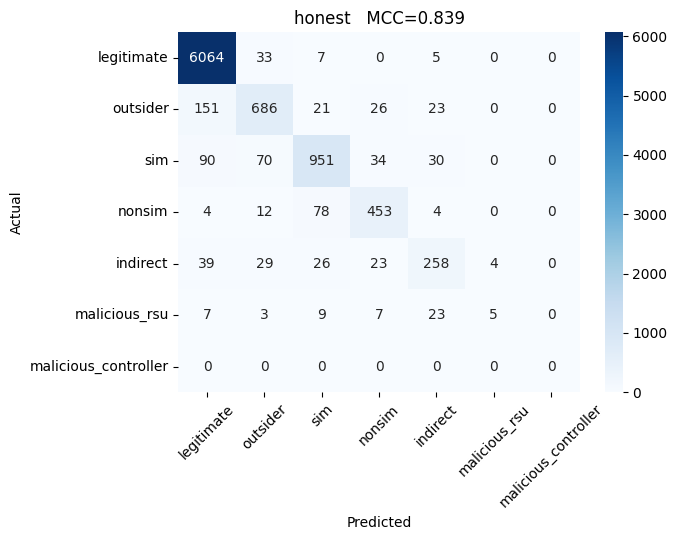

In [8]:
fig, axes = plt.subplots(1, len(FEATURE_SETS), figsize=(7 * len(FEATURE_SETS), 5.5))
if len(FEATURE_SETS) == 1:
    axes = [axes]
yte = y[te]
for ax, (nm, mi) in zip(axes, models.items()):
    pred = mi['model'].predict(feat_df.loc[te, FEATURE_SETS[nm]])
    cm = confusion_matrix(yte, pred, labels=list(range(N_CLASSES)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set(title=f'{nm}   MCC={metrics[nm]["mcc"]:.3f}', xlabel='Predicted', ylabel='Actual')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rssi_xgb_cm.png', dpi=150)
plt.show()

## Step 5 — Export on-contract parquets (`p̄_RSSI = 1 − P(legit)`, Eq 3.19)

In [9]:
# p_bar_rssi(v_i) = 1 − P(class=legit | v_i), scored over ALL windows (train+val+test),
# exported on the shared join key so the RSU ensemble (Eq 3.20) can fuse per window.
KEY = ['run_id', 'attack_percentage', 'claimed_node_id', 'window_start_seconds', 'split']
EXPORTS = {'honest': 'rssi_xgb_rsu.parquet'}        # leakage-free -> feeds the ensemble

for nm, fname in EXPORTS.items():
    feats = FEATURE_SETS[nm]
    fp = full_proba(models[nm]['model'], feat_df[feats])
    out = feat_df[KEY + ['attack_type', 'is_sybil']].copy()
    out['p_bar_rssi'] = (1.0 - fp[:, LEGIT]).astype(np.float32)
    for k in range(N_CLASSES):
        out[f'p_rssi_{k}'] = fp[:, k]
    assert not out.duplicated(subset=KEY).any(), 'duplicate join keys in export'
    path = f'{ARTIFACTS_DIR}/{fname}'
    out.to_parquet(path, index=False)
    print(f'[{nm}] wrote {fname}  {out.shape}  mean p_bar_rssi={out.p_bar_rssi.mean():.3f}')
out.head(3)

[honest] wrote rssi_xgb_rsu.parquet  (54841, 15)  mean p_bar_rssi=0.330


,run_id,attack_percentage,claimed_node_id,window_start_seconds,split,attack_type,is_sybil,p_bar_rssi,p_rssi_0,p_rssi_1,p_rssi_2,p_rssi_3,p_rssi_4,p_rssi_5,p_rssi_6
0,pct100_s1,100,461,2.0,train,1,1,0.467249,0.532751,0.330324,0.048280,0.007024,0.080298,0.001323,0.0
1,pct100_s1,100,461,4.0,train,1,1,0.476260,0.523740,0.438186,0.016839,0.001750,0.018877,0.000608,0.0
2,pct100_s1,100,461,6.0,train,1,1,0.691183,0.308817,0.660248,0.014061,0.001479,0.014797,0.000597,0.0


## Step 6 — Save models & results

In [10]:
for nm, mi in models.items():
    joblib.dump(mi['model'], f'{OUTPUT_DIR}/rssi_xgb_{nm}.pkl')
    joblib.dump(FEATURE_SETS[nm], f'{OUTPUT_DIR}/rssi_xgb_{nm}_features.pkl')

summary = {
    'model'       : 'XGBoost_RSU_7class_v2',
    'window_sec'  : WINDOW_SEC, 'step_sec': STEP_SEC,
    'n_windows'   : int(len(feat_df)),
    'runs'        : feat_df['run_id'].value_counts().to_dict(),
    'feature_sets': FEATURE_SETS,
    'metrics'     : metrics,
}
with open(f'{OUTPUT_DIR}/rssi_xgb_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('=== OUTPUTS ===')
for p in [f'{ARTIFACTS_DIR}/rssi_xgb_rsu.parquet',
          f'{OUTPUT_DIR}/rssi_xgb_honest.pkl',
          f'{OUTPUT_DIR}/rssi_xgb_results.json', f'{OUTPUT_DIR}/rssi_xgb_cm.png']:
    print(f'  [{"OK" if os.path.exists(p) else "MISSING"}]  {p}')
print('\nmetrics:', json.dumps(metrics, indent=2))

=== OUTPUTS ===
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/notebooks/outputs/rssi_xgb_rsu.parquet
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI_XGB/rssi_xgb_honest.pkl
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI_XGB/rssi_xgb_results.json
  [OK]  /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/Outputs_RSSI_XGB/rssi_xgb_cm.png

metrics: {
  "honest": {
    "mcc": 0.8390133832663377,
    "acc": 0.9173841961852861,
    "f1_macro": 0.7170179231251687,
    "sybil_recall": 0.9050880626223092,
    "fpr": 0.007366181044360779,
    "best_depth": 7,
    "val_mcc": 0.84886334739077
  }
}
